# Case Study 3 — SOLUTION: Collections Prioritization

Reference solution for `case3_collections.ipynb`. Uses `data/case3_collections.csv.gz`
(defaulted customers only, targets `RECOVERY_PRIORITY_SCORE` / `PRIORITY_TIER`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

DATA_DIR = "data"
df = pd.read_csv(f"{DATA_DIR}/case3_collections.csv.gz")
print(df.shape)
df.head()


(24825, 43)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,BUREAU_DAYS_CREDIT_MEAN,POS_FULL_MAX_DPD_DEF,CC_FULL_MAX_DPD_DEF,INSTAL_FULL_PCT_LATE,INSTAL_FULL_MAX_DAYS_LATE,EXPOSURE,DPD_SEVERITY,LATE_PCT,RECOVERY_PRIORITY_SCORE,PRIORITY_TIER
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,-874.000000,0.0,NaN,0.000000,-12.0,652378.5,0.0,0.000000,36.1,Tier 4 - Low
1,100031,Cash loans,F,N,Y,0,112500.0,979992.0,27076.5,702000.0,...,-579.571429,NaN,NaN,NaN,NaN,2104992.0,0.0,0.000000,54.6,Tier 2 - High
2,100047,Cash loans,M,N,Y,0,202500.0,1193580.0,35028.0,855000.0,...,-1104.800000,0.0,0.0,0.000000,0.0,4414036.5,0.0,0.000000,58.1,Tier 2 - High
3,100049,Cash loans,F,N,N,0,135000.0,288873.0,16258.5,238500.0,...,-819.142857,0.0,0.0,0.068966,7.0,841315.5,0.0,0.068966,50.2,Tier 2 - High
4,100096,Cash loans,F,N,Y,0,81000.0,252000.0,14593.5,252000.0,...,-2922.000000,NaN,NaN,NaN,NaN,252000.0,0.0,0.000000,22.5,Tier 4 - Low


## Task 1 — Load & Explore

In [2]:
print(df["PRIORITY_TIER"].value_counts())
df[["EXPOSURE", "DPD_SEVERITY", "LATE_PCT", "RECOVERY_PRIORITY_SCORE"]].describe()


PRIORITY_TIER
Tier 4 - Low          6236
Tier 3 - Medium       6213
Tier 1 - Immediate    6197
Tier 2 - High         6179
Name: count, dtype: int64


,EXPOSURE,DPD_SEVERITY,LATE_PCT,RECOVERY_PRIORITY_SCORE
count,2.482500e+04,24825.000000,24825.000000,24825.000000
mean,1.116497e+06,2.683746,0.099060,50.002123
std,1.320054e+06,51.884544,0.135560,16.676370
min,4.500000e+04,0.000000,0.000000,19.100000
25%,4.500000e+05,0.000000,0.000000,37.400000
50%,7.650360e+05,0.000000,0.041667,49.600000
75%,1.321466e+06,0.000000,0.153846,60.800000
max,3.620849e+07,3277.000000,1.000000,99.300000


`PRIORITY_TIER` is built from **quartiles** of `RECOVERY_PRIORITY_SCORE`, so by
construction each tier holds ~25% of accounts — a deliberate design choice so collections
capacity can be planned around a known, stable volume per tier (rather than a fixed
threshold that might put 90% of accounts in one tier if the score distribution shifts).

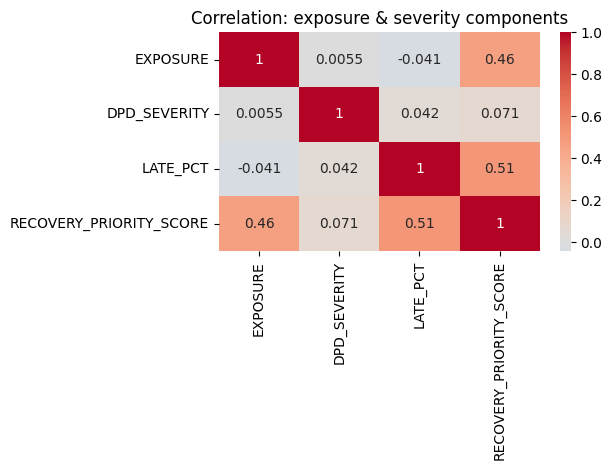

In [3]:
corr_cols = ["EXPOSURE", "DPD_SEVERITY", "LATE_PCT", "RECOVERY_PRIORITY_SCORE"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation: exposure & severity components")
plt.tight_layout()
plt.show()


`EXPOSURE` and `DPD_SEVERITY` are typically only weakly correlated — how much money is
at stake (exposure) is largely independent of how delinquent the account behaviour has been
(severity). This is exactly *why* the score blends both with substantial weights (40% / 35%):
a large, currently-low-DPD account and a small, severely-delinquent account would otherwise
be scored very differently depending on which single factor you used.

## Task 2 — Origination-Only Model

In [4]:
exclude_cols = {
    "SK_ID_CURR", "POS_FULL_MAX_DPD_DEF", "CC_FULL_MAX_DPD_DEF",
    "INSTAL_FULL_PCT_LATE", "INSTAL_FULL_MAX_DAYS_LATE",
    "EXPOSURE", "DPD_SEVERITY", "LATE_PCT",
    "RECOVERY_PRIORITY_SCORE", "PRIORITY_TIER",
}
origination_cols = [c for c in df.columns if c not in exclude_cols]
print(f"{len(origination_cols)} origination-time features")
origination_cols


33 origination-time features


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'BUREAU_COUNT',
 'BUREAU_ACTIVE_COUNT',
 'BUREAU_AMT_CREDIT_SUM_TOTAL',
 'BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL',
 'BUREAU_AMT_CREDIT_SUM_OVERDUE_TOTAL',
 'BUREAU_CREDIT_DAY_OVERDUE_MAX',
 'BUREAU_DAYS_CREDIT_MEAN']

In [5]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[origination_cols].copy()
y = df["RECOVERY_PRIORITY_SCORE"]

cat_cols = X.select_dtypes(include="object").columns.tolist()
for c in cat_cols:
    X[c] = X[c].astype("category")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

reg_origination = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1,
)
reg_origination.fit(X_train, y_train, categorical_feature=cat_cols)
pred_origination = reg_origination.predict(X_val)

r2 = r2_score(y_val, pred_origination)
rho, _ = spearmanr(y_val, pred_origination)
print(f"R^2:               {r2:.4f}")
print(f"Spearman rho:      {rho:.4f}")


/tmp/ipykernel_26447/881362343.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


R^2:               0.4737
Spearman rho:      0.6921


**Why Spearman over R²:** for prioritization, what matters is whether the model gets
the **ordering** of accounts right (does account A get contacted before account B), not
whether it predicts the exact 0-100 score. R² penalizes any miscalibration of scale/shape,
while Spearman rank correlation directly measures ranking quality — which is what
"top-25% capacity" decisions actually depend on.

## Task 3 — How Good Is "Good Enough"?

In [6]:
val_results = pd.DataFrame({
    "true_score": y_val.values,
    "pred_score": pred_origination,
    "true_tier": df.loc[y_val.index, "PRIORITY_TIER"].values,
})
val_results["pred_tier"] = pd.qcut(
    val_results["pred_score"], 4,
    labels=["Tier 4 - Low", "Tier 3 - Medium", "Tier 2 - High", "Tier 1 - Immediate"],
)

from sklearn.metrics import confusion_matrix
tier_order = ["Tier 1 - Immediate", "Tier 2 - High", "Tier 3 - Medium", "Tier 4 - Low"]
cm = confusion_matrix(val_results["true_tier"], val_results["pred_tier"], labels=tier_order)
pd.DataFrame(cm, index=tier_order, columns=tier_order)


,Tier 1 - Immediate,Tier 2 - High,Tier 3 - Medium,Tier 4 - Low
Tier 1 - Immediate,675,339,198,62
Tier 2 - High,499,407,189,147
Tier 3 - Medium,67,484,454,248
Tier 4 - Low,0,11,400,785


In [7]:
# Top-25% capacity: what fraction of TRUE Tier 1 accounts fall in the predicted top 25%?
n_capacity = int(0.25 * len(val_results))
contacted = val_results.sort_values("pred_score", ascending=False).head(n_capacity)

true_tier1 = val_results[val_results["true_tier"] == "Tier 1 - Immediate"]
captured = contacted[contacted["true_tier"] == "Tier 1 - Immediate"]

capture_rate = len(captured) / len(true_tier1)
print(f"True Tier 1 accounts: {len(true_tier1)}")
print(f"Captured in top-25% contacted: {len(captured)}")
print(f"Capture rate: {capture_rate:.2%}")


True Tier 1 accounts: 1274
Captured in top-25% contacted: 675
Capture rate: 52.98%


A capture rate meaningfully above 25% (the rate a random/no-model approach would
achieve) demonstrates the origination-only model adds real value — collections teams reach
a disproportionate share of the truly highest-priority accounts using only information
available on day one. Whether it's "good enough" depends on collections capacity and the
cost of missed high-priority accounts vs. the cost of building/maintaining the
behavioural-data pipeline needed for Task 4's full model.

## Task 4 — Full-Feature Model (Sanity Check)

In [8]:
full_cols = [c for c in df.columns if c not in {"SK_ID_CURR", "RECOVERY_PRIORITY_SCORE", "PRIORITY_TIER"}]
X_full = df[full_cols].copy()
cat_cols_full = X_full.select_dtypes(include="object").columns.tolist()
for c in cat_cols_full:
    X_full[c] = X_full[c].astype("category")

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_full, y, test_size=0.2, random_state=42)

reg_full = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1,
)
reg_full.fit(X_train_f, y_train_f, categorical_feature=cat_cols_full)
pred_full = reg_full.predict(X_val_f)

print(f"R^2:          {r2_score(y_val_f, pred_full):.4f}")
print(f"Spearman rho: {spearmanr(y_val_f, pred_full)[0]:.4f}")


/tmp/ipykernel_26447/4275800841.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_full = X_full.select_dtypes(include="object").columns.tolist()


R^2:          0.9997
Spearman rho: 0.9999


As expected, R² is near 1.0 — `RECOVERY_PRIORITY_SCORE` is a **deterministic function**
of `EXPOSURE`, `DPD_SEVERITY`, and `LATE_PCT`, so a model with access to those inputs
trivially reproduces it. The "practical use" of this model isn't prediction at all — it's
a **sanity check** that the formula and pipeline are implemented correctly, and a tool to
inspect feature importances/weights when the underlying formula is *not* known (e.g. if
the business rule were more complex or undocumented).

In [9]:
imp_origination = pd.Series(reg_origination.feature_importances_, index=origination_cols).sort_values(ascending=False)
imp_full = pd.Series(reg_full.feature_importances_, index=full_cols).sort_values(ascending=False)

print("Top 5 - origination-only model:")
print(imp_origination.head(5))
print("\nTop 5 - full-feature model:")
print(imp_full.head(5))


Top 5 - origination-only model:
ORGANIZATION_TYPE                   663
BUREAU_DAYS_CREDIT_MEAN             607
EXT_SOURCE_3                        605
BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL    570
EXT_SOURCE_2                        548
dtype: int32

Top 5 - full-feature model:
INSTAL_FULL_PCT_LATE         2422
EXPOSURE                     2399
DPD_SEVERITY                  893
POS_FULL_MAX_DPD_DEF          324
INSTAL_FULL_MAX_DAYS_LATE     246
dtype: int32


In the full-feature model, `EXPOSURE`, `DPD_SEVERITY`, and `LATE_PCT` dominate
importances almost entirely (consistent with the 0.40/0.35/0.25 weighting in the formula —
`EXPOSURE` slightly ahead of `DPD_SEVERITY`, both well ahead of `LATE_PCT`). The
origination-only model instead spreads importance across `EXT_SOURCE_*`, income/credit
ratios, and `BUREAU_*` debt features — proxies that *correlate* with eventual exposure and
severity but aren't the same thing. This confirms Task 1's finding: exposure and severity
are largely independent signals, both of which the score formula explicitly captures, but
which origination-time data can only partially anticipate.

## Task 5 — Stretch: Operational Design

**Scoring cadence:** Both models have a role. The **origination-time model (Task 2)**
should score every new defaulted account *immediately* — at the moment of default, before
any collections-specific data (current exposure trend, DPD history) has accumulated, this
is the only signal available, and it lets the team triage on day one. The **full-feature
model (Task 4)** — or really, the underlying formula directly — should then be recomputed
**periodically** (e.g. weekly) as `EXPOSURE`, `DPD_SEVERITY`, and `LATE_PCT` evolve, refining
the priority as better information arrives. In practice the origination model's output
could serve as a prior/tiebreaker until enough behavioural data exists to compute the full
score reliably.

**Validation via A/B test:** Randomly assign newly-defaulted accounts to either (a) the
model-prioritized contact order, or (b) the existing/baseline contact order (e.g. FIFO or
exposure-only). Compare recovery rate (% of exposure recovered within N days) and
time-to-first-contact for high-priority accounts between arms. Guard against contamination
by ensuring collections agents don't have visibility into which arm an account belongs to
beyond the assigned contact order.

**Fairness/compliance:** Using `NAME_EDUCATION_TYPE`, `OCCUPATION_TYPE`, or
`ORGANIZATION_TYPE` to influence *who gets contacted first for debt collection* risks
disparate treatment of protected or quasi-protected groups (e.g. certain occupations
correlating with race/ethnicity or socioeconomic status), even if unintentional. Best
practice: exclude such features from the prioritization model entirely, or at minimum run
a disparate-impact analysis (compare contact-priority distributions across demographic
groups) before deployment, and ensure the *outcome* (contact order/timing) doesn't
systematically disadvantage any protected group beyond what's explained by `EXPOSURE`/
`DPD_SEVERITY`/`LATE_PCT` alone.